# Proyecto: Clasificación de Subgéneros de Jazz (FMA)

## 1. Configuración del Entorno y Almacenamiento

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight


import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler

import librosa

import matplotlib.pyplot as plt
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [47]:
# Rutas relativas (asumiendo que el notebook está en /notebooks y los datos en /data)
DATA_DIR = "../data/"

print("Cargando matrices preprocesadas...")
X_tabular = np.load(f"{DATA_DIR}X_tabular.npy")
X_cnn = np.load(f"{DATA_DIR}X_cnn.npy")
y_encoded = np.load(f"{DATA_DIR}y_encoded.npy")
classes = np.load(f"{DATA_DIR}classes.npy")

print(f"Forma de X_tabular (Random Forest): {X_tabular.shape}")
print(f"Forma de X_cnn (Red Neuronal): {X_cnn.shape}")
print(f"Clases detectadas: {classes}")

# Train/Test Split común para ambos
X_train_t, X_test_t, y_train, y_test = train_test_split(X_tabular, y_encoded, test_size=0.2, random_state=42)
X_train_m, X_test_m, _, _ = train_test_split(X_cnn, y_encoded, test_size=0.2, random_state=42)
todas_las_clases = np.arange(len(classes))

Cargando matrices preprocesadas...
Forma de X_tabular (Random Forest): (613, 74)
Forma de X_cnn (Red Neuronal): (613, 128, 128, 1)
Clases detectadas: ['Big Band/Swing' 'Free-Jazz' 'Jazz Generico' 'Jazz: Out' 'Jazz: Vocal'
 'Modern Jazz']


In [59]:
print("--- Balanceando datos con SMOTE ---")

# 1. Averiguar el tamaño de la clase más pequeña en nuestro set de entrenamiento
conteo_clases = Counter(y_train)
min_muestras = min(conteo_clases.values())

# 2. Configurar los vecinos: SMOTE necesita que k_neighbors sea estrictamente 
# menor que la cantidad de muestras de la clase más pequeña.
k_vecinos = min(5, min_muestras - 1)

# 3. Lógica de seguridad (Fallback)
if k_vecinos < 1:
    print(f"¡Advertencia! La clase más pequeña tiene solo {min_muestras} muestra(s).")
    print("SMOTE requiere al menos 2. Usando RandomOverSampler (Clonación directa) como respaldo.")
    sampler = RandomOverSampler(random_state=42)
else:
    print(f"La clase más pequeña tiene {min_muestras} muestras.")
    print(f"Configurando SMOTE dinámico con k_neighbors={k_vecinos}")
    sampler = SMOTE(k_neighbors=k_vecinos, random_state=42)

# 4. Aplicar el balanceo seguro
X_train_t_smote, y_train_smote = sampler.fit_resample(X_train_t, y_train)

print(f"Distribución antes: {dict(conteo_clases)}")
print(f"Distribución después: {dict(Counter(y_train_smote))}")

print("--- Optimizando Random Forest con Búsqueda Aleatoria ---")
# Definimos una "cuadrícula" de posibles configuraciones para el bosque
param_grid = {
    'n_estimators': [100, 200, 400, 600],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

# Prueba 200 combinaciones distintas al azar buscando la mejor (n_iter=200)
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=param_grid, 
                               n_iter=200, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Entrenamos usando los datos que ya balanceamos con SMOTE previamente
rf_random.fit(X_train_t_smote, y_train_smote)

print("\n[!] ¡Búsqueda terminada!")
print(f"Mejores parámetros encontrados: {rf_random.best_params_}")

# Predecimos con el mejor modelo encontrado
mejor_rf = rf_random.best_estimator_
y_pred_rf_opt = mejor_rf.predict(X_test_t)

print("\n=== REPORTE RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf_opt, labels=todas_las_clases, target_names=classes, zero_division=0))

--- Balanceando datos con SMOTE ---
La clase más pequeña tiene 15 muestras.
Configurando SMOTE dinámico con k_neighbors=5
Distribución antes: {5: 51, 2: 204, 0: 15, 3: 44, 4: 43, 1: 133}
Distribución después: {5: 204, 2: 204, 0: 204, 3: 204, 4: 204, 1: 204}
--- Optimizando Random Forest con Búsqueda Aleatoria ---
Fitting 3 folds for each of 200 candidates, totalling 600 fits

[!] ¡Búsqueda terminada!
Mejores parámetros encontrados: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}

=== REPORTE RANDOM FOREST ===
                precision    recall  f1-score   support

Big Band/Swing       1.00      0.67      0.80         3
     Free-Jazz       0.88      0.66      0.75        35
 Jazz Generico       0.62      0.89      0.73        46
     Jazz: Out       0.86      0.46      0.60        13
   Jazz: Vocal       0.62      0.62      0.62         8
   Modern Jazz       0.86      0.67      0.75        18

      accuracy                   

In [53]:
print("--- Configurando CNN con Data Augmentation ---")
# Pesos suavizados (Clipping)
pesos_crudos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_suavizados = np.clip(pesos_crudos, a_min=1.0, a_max=4.0)
pesos_dict = dict(enumerate(pesos_suavizados))

# Generador de imágenes alteradas
datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, fill_mode='nearest')

print("\n--- Entrenando CNN  ---")

cnn_model_opt = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    
    layers.Conv2D(16, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(),  # En vez de Flatten
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.4),
    layers.Dense(len(classes), activation='softmax')
])

cnn_model_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks: Si la red deja de mejorar por 10 épocas, se detiene sola. 
# Si se estanca, reduce la velocidad de aprendizaje.
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Entrenamos DIRECTAMENTE sobre X_train_m (sin el datagen que rompía la imagen)
history = cnn_model_opt.fit(
    X_train_m, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_m, y_test),
    #class_weight=pesos_dict, # Seguimos usando los pesos suavizados
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_cnn_opt = np.argmax(cnn_model_opt.predict(X_test_m), axis=1)

print("\n=== REPORTE CNN ===")
print(classification_report(y_test, y_pred_cnn_opt, labels=todas_las_clases, target_names=classes, zero_division=0))

--- Configurando CNN con Data Augmentation ---

--- Entrenando CNN  ---
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3041 - loss: 1.9925 - val_accuracy: 0.3740 - val_loss: 1.8896 - learning_rate: 3.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3510 - loss: 1.7407 - val_accuracy: 0.3740 - val_loss: 1.8824 - learning_rate: 3.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3939 - loss: 1.6547 - val_accuracy: 0.3740 - val_loss: 1.8720 - learning_rate: 3.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4184 - loss: 1.5991 - val_accuracy: 0.3902 - val_loss: 1.8585 - learning_rate: 3.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4510 - loss: 1.5656 - val_accuracy: 0.2358 - val_loss: 1.8402 - learning_rate: 3.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4633 - loss: 1.5008 - val_accuracy: 0.2846 - val_loss: 1.8314 - learning_rate: 3.0

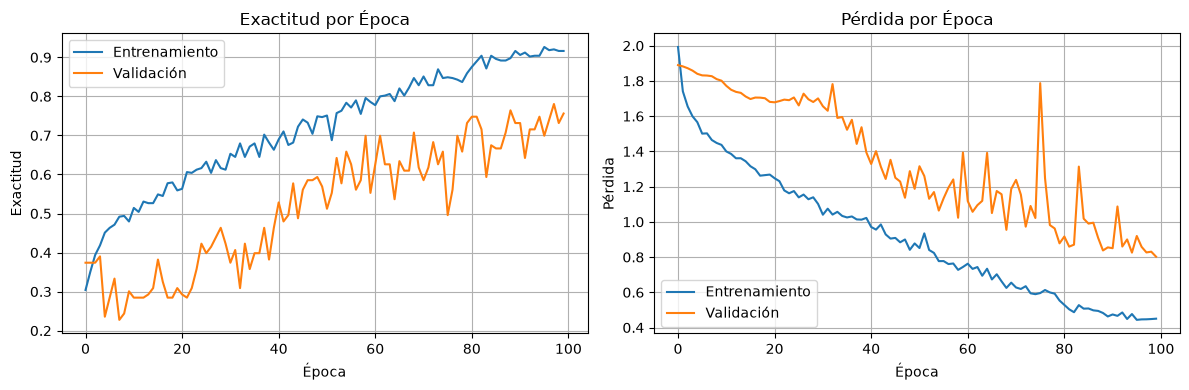

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Exactitud')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../report/figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

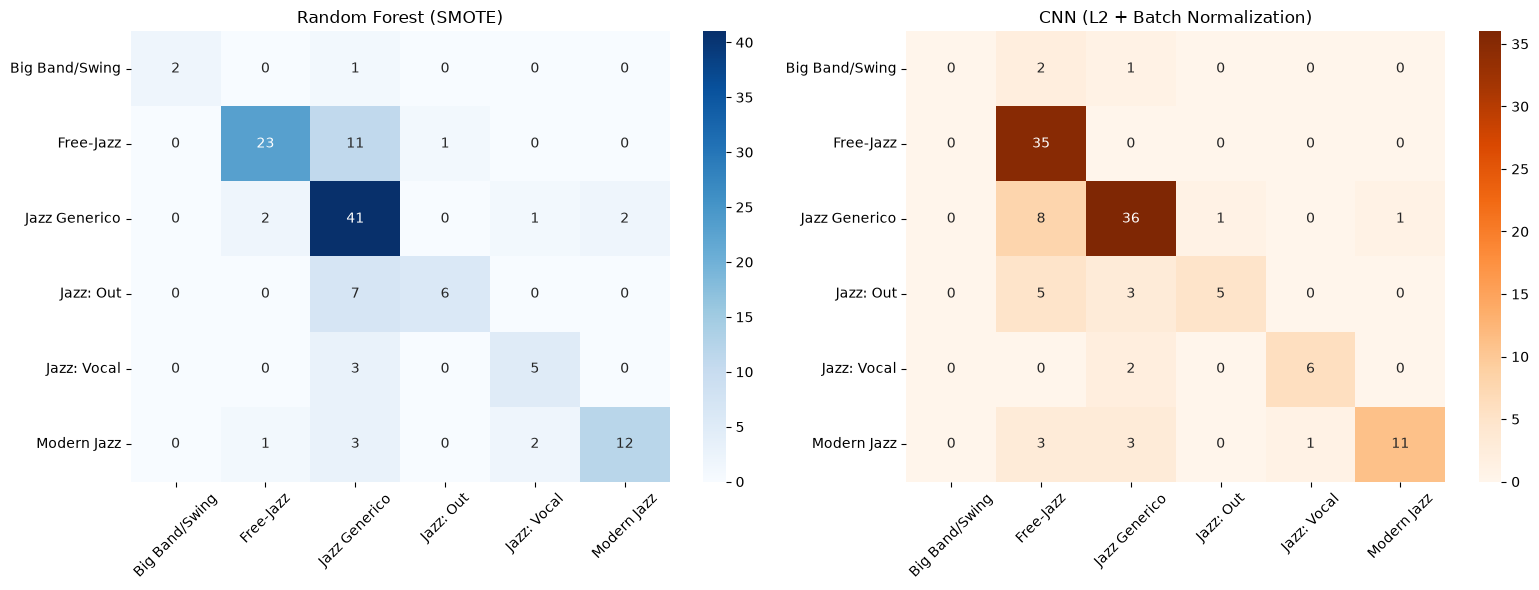

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt, labels=todas_las_clases), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set_title('Random Forest (SMOTE)')
ax[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(y_test, y_pred_cnn_opt, labels=todas_las_clases), 
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title('CNN (L2 + Batch Normalization)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../report/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
print("--- CREANDO EL ENSAMBLE HÍBRIDO (WEIGHTED SOFT VOTING) ---")

# 1. Pedirle a los modelos su % de seguridad (probabilidades) con los datos de prueba
# (Asegúrate de usar los nombres de variables correctos que tienes en tu notebook)
probs_rf = mejor_rf.predict_proba(X_test_t) # El mejor Random Forest del GridSearch
probs_cnn = cnn_model_opt.predict(X_test_m) # La CNN optimizada

# 2. El Comité Vota: Le damos 75% de peso al RF y 25% a la CNN
probs_ensamble = (probs_rf * 0.75) + (probs_cnn * 0.25)

# 3. La decisión final es la clase con la probabilidad sumada más alta
y_pred_ensamble = np.argmax(probs_ensamble, axis=1)

print("\n=== REPORTE ENSAMBLE HÍBRIDO FINAL ===")
print(classification_report(y_test, y_pred_ensamble, labels=todas_las_clases, target_names=classes, zero_division=0))

--- CREANDO EL ENSAMBLE HÍBRIDO (WEIGHTED SOFT VOTING) ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

=== REPORTE ENSAMBLE HÍBRIDO FINAL ===
                precision    recall  f1-score   support

Big Band/Swing       1.00      0.67      0.80         3
     Free-Jazz       0.86      0.86      0.86        35
 Jazz Generico       0.69      0.89      0.78        46
     Jazz: Out       0.89      0.62      0.73        13
   Jazz: Vocal       0.75      0.38      0.50         8
   Modern Jazz       0.93      0.72      0.81        18

      accuracy                           0.79       123
     macro avg       0.85      0.69      0.75       123
  weighted avg       0.81      0.79      0.78       123



### Testing

In [65]:
def predecir_cancion_nueva(ruta_mp3, modelo_rf, modelo_cnn, clases_nombres):
    """
    Toma cualquier archivo MP3, extrae su cinemática y su espectrograma,
    y hace que el Ensamble Híbrido vote para predecir su subgénero de Jazz.
    """
    print(f"E scuchando e interpretando pista: {ruta_mp3}...")
    
    try:
        # 1. Cargar los primeros 30 segundos del audio
        y, sr = librosa.load(ruta_mp3, duration=30)
        
        # 2. Extraer Características Físicas (Matemáticas)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        delta_mfccs = librosa.feature.delta(mfccs)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        
        feat_tabular = np.hstack([
            np.mean(mfccs.T, axis=0),
            np.mean(delta_mfccs.T, axis=0),
            np.mean(delta2_mfccs.T, axis=0),
            np.mean(chroma.T, axis=0),
            np.mean(rolloff),   
            np.mean(zcr)        
        ]).reshape(1, -1) # Reshape porque es 1 sola canción
        
        # 3. Extraer Características Visuales (Espectrograma para CNN)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Normalizar:
        mel_db_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        mel_resized = tf.image.resize(mel_db_norm[..., np.newaxis], [128, 128]).numpy()
        feat_cnn = mel_resized.reshape(1, 128, 128, 1)

        # 4. El Comité Vota (Predicción)
        prob_rf = modelo_rf.predict_proba(feat_tabular)
        prob_cnn = modelo_cnn.predict(feat_cnn, verbose=0)
        
        # Pesos del ensamble (50% Random Forest, 50% CNN)
        prob_final = (prob_rf * 0.5) + (prob_cnn * 0.5)
        
        # 5. Obtener el ganador
        indice_ganador = np.argmax(prob_final, axis=1)[0]
        confianza = np.max(prob_final) * 100
        genero_predicho = clases_nombres[indice_ganador]
        
        print("\n" + "="*40)
        print(f"¡ANÁLISIS COMPLETADO!")
        print(f"Subgénero detectado: {genero_predicho.upper()}")
        print(f"Nivel de Confianza: {confianza:.2f}%")
        print("="*40 + "\n")
        
        return genero_predicho
        
    except Exception as e:
        print(f"Error al procesar el audio: {e}")

In [64]:
# Reemplaza 'mi_audio' con el nombre de la canción que descargues
TEST_AUDIO_DIR = "../data/test_audio/"
mi_audio = "test2.mp3" 
ruta_audio = TEST_AUDIO_DIR + mi_audio

# Asumiendo que tus modelos se llaman mejor_rf y cnn_model_opt
predecir_cancion_nueva(ruta_audio, mejor_rf, cnn_model_opt, classes)

E scuchando e interpretando pista: ../data/test_audio/test2.mp3...

¡ANÁLISIS COMPLETADO!
Subgénero detectado: JAZZ GENERICO
Nivel de Confianza: 43.75%



'Jazz Generico'